**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Device Configuration](#toc2_)    
- [Constants](#toc3_)    
- [Understanding Data](#toc4_)    
  - [Helper functions](#toc4_1_)    
  - [Train data - Germany: 2018-242N](#toc4_2_)    
    - [Meta info](#toc4_2_1_)    
    - [Timestamps](#toc4_2_2_)    
    - [Area Cordinates](#toc4_2_3_)    
    - [Load Train Data](#toc4_2_4_)    
    - [Load mask](#toc4_2_5_)    
    - [Load the json and train labels](#toc4_2_6_)    
- [Handling data](#toc5_)    
  - [Helper functions](#toc5_1_)    
    - [To display image(s)](#toc5_1_1_)    
  - [Save the labels and first timestamp as .npy files for further use](#toc5_2_)    
    - [Save data slice](#toc5_2_1_)    
    - [Save labels](#toc5_2_2_)    
  - [EVI calculation and Dividing data into patches](#toc5_3_)    
    - [Normalisation](#toc5_3_1_)    
    - [Calculate the vegetation indexs](#toc5_3_2_)    
    - [Save the vegetation data or future use](#toc5_3_3_)    
    - [Dividing labels into 64*64 with overlap by 50%](#toc5_3_4_)    
    - [Dividing data into 64*64 with overlap by 50%](#toc5_3_5_)    
  - [Filtering Data](#toc5_4_)    
    - [Removing pathes with images with no data pixels above a set threshold](#toc5_4_1_)    
    - [Visualise class distribution before traditional augumentation](#toc5_4_2_)    
    - [Segregate the labels based on the class](#toc5_4_3_)    
- [Data Augumentation](#toc6_)    
  - [Visualising sample agugumentation](#toc6_1_)    
  - [Augumentation by class](#toc6_2_)    
    - [Save augmented and original(filtered) data](#toc6_2_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [ ]:
import pickle
import pickletools
import datetime
from eolearn.core import EOPatch
from pyproj import Proj, transform

import numpy as np
import pandas as pd

import geopandas as gpd
import rasterio as rio
from rasterio import features

from patchify import patchify

import torch

import matplotlib.pyplot as plt

#library to help perform traditional agumenattions
import albumentations as TA
from tqdm import tqdm


# <a id='toc2_'></a>[Device Configuration](#toc0_)

In [4]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cuda:0


# <a id='toc3_'></a>[Constants](#toc0_)

- Sentinel 2 Bands information
-------------------------------
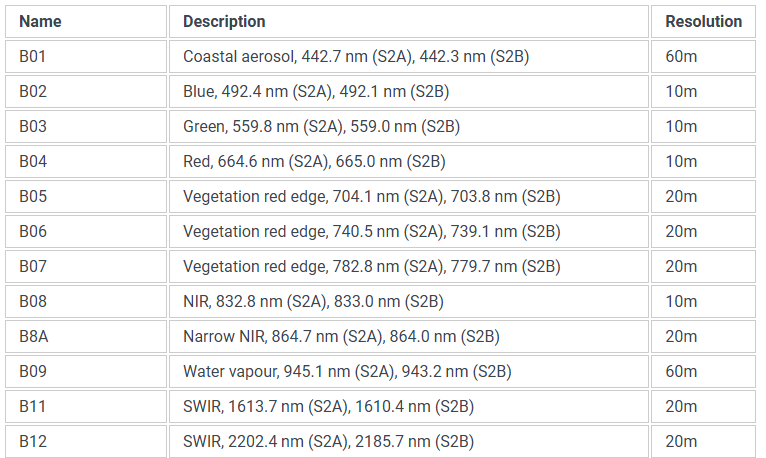

In [ ]:
BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BAND_CLASSES = ["COSTAL_AEROSOL", "BLUE", "GREEN", "RED",
                "VEGETATION_RED_EDGE-704NM", "VEGETATION_RED_EDGE-740NM",
                "VEGETATION_RED_EDGE-782NM", "NIR","NARROW_NIR", "WATER_VAPOUR",
                "SWIR-1612NM","SWIR-2202NM"]

CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# <a id='toc4_'></a>[Understanding Data](#toc0_)

## <a id='toc4_1_'></a>[Helper functions](#toc0_)

In [ ]:
def formatCordinates(cordinate): 
    # Define the UTM projection (for example, UTM Zone 33N)
    utm_proj = Proj(proj="utm", zone=33, datum="WGS84")
    
    # Define the WGS84 (lat, lon) projection
    latlon_proj = Proj(proj="latlong", datum="WGS84")
    
    # Convert UTM to Latitude/Longitude
    longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
    
    print(f"Latitude = {latitude}, Longitude = {longitude}")


## <a id='toc4_2_'></a>[Train data - Germany: 2018-242N](#toc0_)

In [ ]:
user_path = 'C:/Users/Sai Suhaas' 
base_path_2018_242N = user_path + '/Desktop/Dissertation/Farmland-Classification-using-Remote-Sensing/Dataset/s2-utm-33N-18E-242N-2018'
train_geojson_path  = user_path + '/Desktop/Dissertation/Farmland-Classification-using-Remote-Sensing/Dataset/br-18E-242N-crop-labels-train-2018.geojson'


### <a id='toc4_2_1_'></a>[Meta info](#toc0_)

In [ ]:
# Replace 'filename.pkl' with the path to your pickle file
path = base_path_2018_242N + '/meta_info.pkl'

with open(path, 'rb') as file:
    pickled_data = pickletools.dis(file)


    0: \x80 PROTO      3
    2: c    GLOBAL     'eolearn.core.eodata _FeatureDict'
   36: q    BINPUT     0
   38: )    EMPTY_TUPLE
   39: \x81 NEWOBJ
   40: q    BINPUT     1
   42: (    MARK
   43: X        BINUNICODE 'size_x'
   54: q        BINPUT     2
   56: M        BININT2    2400
   59: X        BINUNICODE 'size_y'
   70: q        BINPUT     3
   72: M        BININT2    2400
   75: X        BINUNICODE 'time_interval'
   93: q        BINPUT     4
   95: c        GLOBAL     'datetime datetime'
  114: q        BINPUT     5
  116: C        SHORT_BINBYTES b'\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00'
  128: q        BINPUT     6
  130: \x85     TUPLE1
  131: q        BINPUT     7
  133: R        REDUCE
  134: q        BINPUT     8
  136: h        BINGET     5
  138: C        SHORT_BINBYTES b'\x07\xe2\x0c\x1f\x17;;\x00\x00\x00'
  150: q        BINPUT     9
  152: \x85     TUPLE1
  153: q        BINPUT     10
  155: R        REDUCE
  156: q        BINPUT     11
  158: \x86     TUPLE2
 

In [ ]:
with open(path, 'rb') as file:
    data = file.read()  # Read the first 100 bytes
    print(data)


b'\x80\x03ceolearn.core.eodata\n_FeatureDict\nq\x00)\x81q\x01(X\x06\x00\x00\x00size_xq\x02M`\tX\x06\x00\x00\x00size_yq\x03M`\tX\r\x00\x00\x00time_intervalq\x04cdatetime\ndatetime\nq\x05C\n\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00q\x06\x85q\x07Rq\x08h\x05C\n\x07\xe2\x0c\x1f\x17;;\x00\x00\x00q\t\x85q\nRq\x0b\x86q\x0cX\x05\x00\x00\x00maxccq\rK\x01X\x0f\x00\x00\x00time_differenceq\x0ecdatetime\ntimedelta\nq\x0fK\x00M \x1cK\x00\x87q\x10Rq\x11u}q\x12(X\x0c\x00\x00\x00feature_typeq\x13ceolearn.core.constants\nFeatureType\nq\x14X\t\x00\x00\x00meta_infoq\x15\x85q\x16Rq\x17X\x04\x00\x00\x00ndimq\x18NX\t\x00\x00\x00is_vectorq\x19\x89ub.'


### <a id='toc4_2_2_'></a>[Timestamps](#toc0_)

In [5]:
path = base_path_2018_242N + '/timestamp.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = pickle.load(file)

        readable_dates = [dt.strftime("%Y-%m-%d %H:%M:%S") for dt in data]
    
        # Now 'data' contains the contents of the pickle file
        #print(readable_dates)

        print(f"Start date: {min(readable_dates)}\nEnd Date: {max(readable_dates)}")
        print(f"No of timestamps: {len(readable_dates)}")
except Exception as e:
    print(f"An error occurred: {e}")


Start date: 2018-01-02 10:24:20
End Date: 2018-12-30 10:16:06
No of timestamps: 144


In [ ]:
for x,i in enumerate(readable_dates):
    print(x,i)


0 2018-01-02 10:24:20
1 2018-01-04 10:14:03
2 2018-01-07 10:24:01
3 2018-01-09 10:15:36
4 2018-01-12 10:23:55
5 2018-01-14 10:13:47
6 2018-01-17 10:23:41
7 2018-01-19 10:13:31
8 2018-01-22 10:23:23
9 2018-01-24 10:13:52
10 2018-01-27 10:23:14
11 2018-01-29 10:12:47
12 2018-02-01 10:22:37
13 2018-02-03 10:12:37
14 2018-02-06 10:22:06
15 2018-02-08 10:11:53
16 2018-02-11 10:21:39
17 2018-02-13 10:11:18
18 2018-02-16 10:21:02
19 2018-02-18 10:13:13
20 2018-02-21 10:20:33
21 2018-02-23 10:15:08
22 2018-02-26 10:20:50
23 2018-02-28 10:10:21
24 2018-03-03 10:20:19
25 2018-03-05 10:13:15
26 2018-03-08 10:22:41
27 2018-03-10 10:10:20
28 2018-03-13 10:25:40
29 2018-03-15 10:10:38
30 2018-03-18 10:20:16
31 2018-03-20 10:10:21
32 2018-03-23 10:20:21
33 2018-03-25 10:15:11
34 2018-03-28 10:20:18
35 2018-03-30 10:14:39
36 2018-04-02 10:24:35
37 2018-04-04 10:10:21
38 2018-04-07 10:20:20
39 2018-04-09 10:13:43
40 2018-04-12 10:20:24
41 2018-04-14 10:15:36
42 2018-04-17 10:20:21
43 2018-04-19 10:14:5

### <a id='toc4_2_3_'></a>[Area Cordinates](#toc0_)

In [ ]:
path = base_path_2018_242N + '/bbox.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = list(pickle.load(file))

        # Now 'data' contains the contents of the pickle file
        print("Start point: ")
        formatCordinates(data[:2])
        print("End point: ")
        formatCordinates(data[2:])
except Exception as e:
    print(f"An error occurred: {e}")


Start point: 
Latitude = 52.417989999999996, Longitude = 14.000120000000003
End point: 
Latitude = 52.63620000888608, Longitude = 14.349811619358587


C:\Users\Sai Suhaas\AppData\Local\Temp\ipykernel_8636\2877271017.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
C:\Users\Sai Suhaas\AppData\Local\Temp\ipykernel_8636\2877271017.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])


### <a id='toc4_2_4_'></a>[Load Train Data](#toc0_)

In [ ]:
path = base_path_2018_242N + '/BANDS.npy'

# Load the .npy file
data_2018_242N = np.load(path)


In [ ]:
# Now 'data' holds the contents of the file
print(data_2018_242N.shape)



(144, 2400, 2400, 12)


### <a id='toc4_2_5_'></a>[Load mask](#toc0_)

In [ ]:
path = base_path_2018_242N + '/SCL.npy'
cloud_mask_2018_242N = np.load(path)


In [ ]:
print(cloud_mask_2018_242N.shape)

print(np.unique(cloud_mask_2018_242N[:][:][:]))


(144, 2400, 2400, 1)
[ 0  2  3  4  5  6  7  8  9 10 11]


### <a id='toc4_2_6_'></a>[Load the json and train labels](#toc0_)

In [ ]:
min_area = 500 # in meters/square
labels = gpd.read_file(train_geojson_path)

with open((base_path_2018_242N + '/bbox.pkl'), 'rb') as f:
            bbox = pickle.load(f)
            crs = str(bbox.crs)
            minx, miny, maxx, maxy = bbox.min_x, bbox.min_y, bbox.max_x, bbox.max_y

# project to same coordinate reference system (crs) as the imagery
labels = labels.to_crs(crs)

mask = labels.geometry.area > min_area
print(f"ignoring {(~mask).sum()}/{len(mask)} fields with area < {min_area}m2")
labels = labels.loc[mask]

#self.bands = np.load(os.path.join(rootpath, "data", "BANDS.npy"))
#self.clp = np.load(os.path.join(rootpath, "data", "CLP.npy"))
# bands = np.concatenate([bands, clp], axis=-1) # concat cloud probability
_, width, height, _ = data_2018_242N.shape

transform = rio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

fid_mask = features.rasterize(zip(labels.geometry, labels.fid), 
                              all_touched=True,
                              transform=transform, 
                              out_shape=(height, width),
                              default_value=-1,
                              nodata=-1)

assert len(np.unique(fid_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                     f"Does the label geojson {train_geojson_path} cover the region defined by {base_path_2018_242N}?"

crop_mask = features.rasterize(zip(labels.geometry, labels.crop_id),
                               all_touched=True,
                               transform=transform,
                               out_shape=(height, width),
                               default_value=-1,
                               nodata=-1)

assert len(np.unique(crop_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                      f"Does the label geojson {train_geojson_path} cover the region defined by {base_path_2018_242N}?"

#Replace 0 with -1 to indicate clear difference between the no data areaa
#To be noted while defining loss function to make discourage class imbalance
crop_mask = np.where(crop_mask == 0, -1, crop_mask)


ignoring 13/2534 fields with area < 500m2


In [ ]:
print(crop_mask.shape)
print(np.unique(crop_mask, return_counts=True))


(2400, 2400)
(array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([2797961,  623835,  453365,  279643,   48665,  544897,  507156,
         16917,  262077,  225484], dtype=int64))


# <a id='toc5_'></a>[Handling data](#toc0_)

## <a id='toc5_1_'></a>[Helper functions](#toc0_)

### <a id='toc5_1_1_'></a>[To display image(s)](#toc0_)

In [ ]:
def display_images(data_patches):
    for i in range(data_patches.shape[0]):
        patch = data_patches[i,...]
        indices = [patch[...,0], patch[...,1], patch[...,2], patch[...,3]]
        titles = ['EVI', 'NDWI', 'GNDVI', 'NDRE']

        fig, axs = plt.subplots(1, 4, figsize=(16, 4))
        for ax, idx_map, title in zip(axs, indices, titles):
            im = ax.imshow(idx_map, cmap='RdYlGn', vmin=-1, vmax=1)
            ax.set_title(title)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()


## <a id='toc5_2_'></a>[Save the labels and first timestamp as .npy files for further use](#toc0_)

In [ ]:
data_2018_242N_start_date = data_2018_242N[0, :, :, :]

print(data_2018_242N_start_date.shape)


(2400, 2400, 12)


In [ ]:
#View data
print(data_2018_242N_start_date[1,:10,:1])


[[549]
 [549]
 [549]
 [549]
 [549]
 [549]
 [342]
 [342]
 [342]
 [342]]


In [ ]:
#Load data for 31 July, 2018 as it has minimum cloud cover which can be helpfull for GAN generated images
data_2018_242N_31_July = data_2018_242N[83, :, :, :]

print(data_2018_242N_31_July.shape)


(2400, 2400, 12)


In [ ]:
#View data
print(data_2018_242N_31_July[1,:10,:1])


[[211]
 [211]
 [211]
 [211]
 [211]
 [211]
 [235]
 [235]
 [235]
 [235]]


### <a id='toc5_2_1_'></a>[Save data slice](#toc0_)

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-01-02.npy', data_2018_242N_start_date)


In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy', data_2018_242N_31_July)


### <a id='toc5_2_2_'></a>[Save labels](#toc0_)

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/labels.npy',crop_mask) 


## <a id='toc5_3_'></a>[EVI calculation and Dividing data into patches](#toc0_)

In [ ]:
bands_data_start_date_path = r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-01-02.npy'
bands_data_31_july_path = r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy'
train_labels_path = r'../Dataset/s2-utm-33N-18E-242N-2018/labels.npy'


### <a id='toc5_3_1_'></a>[Normalisation](#toc0_)

In [24]:
train_data_2018_31_july = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy')

# Convert the numpy array to a tensor and move it to the specified device (GPU or CPU)
train_tensor_data = torch.tensor(train_data_2018_31_july, dtype=torch.float32).to(DEVICE)

# Initialize normalized array (keeping it on the GPU)
normalized_train_data = torch.empty_like(train_tensor_data, dtype=torch.float32).to(DEVICE)

# Apply 2nd–98th percentile normalization per band
for b in range(train_tensor_data.shape[-1]):
    band_data = train_tensor_data[..., b]
    flat = band_data.view(-1)  # Flatten the data

    # Compute 2nd and 98th percentiles directly on the GPU
    p2 = torch.quantile(flat, 0.02)
    p98 = torch.quantile(flat, 0.98)
    
    # Normalize the band
    norm_band = (band_data - p2) / (p98 - p2 + 1e-8)
    
    # Clamp values between 0 and 1
    norm_band = torch.clamp(norm_band, 0, 1)
    
    # Store normalized band
    normalized_train_data[..., b] = norm_band


    # After normalization, check the min and max values for each band
    min_value = normalized_train_data[..., b].min().item()  # Min for the b-th band
    max_value = normalized_train_data[..., b].max().item()  # Max for the b-th band
    
    print(f"Band {b} - Min value: {min_value}, Max value: {max_value}")


Band 0 - Min value: 0.0, Max value: 1.0
Band 1 - Min value: 0.0, Max value: 1.0
Band 2 - Min value: 0.0, Max value: 1.0
Band 3 - Min value: 0.0, Max value: 1.0
Band 4 - Min value: 0.0, Max value: 1.0
Band 5 - Min value: 0.0, Max value: 1.0
Band 6 - Min value: 0.0, Max value: 1.0
Band 7 - Min value: 0.0, Max value: 1.0
Band 8 - Min value: 0.0, Max value: 1.0
Band 9 - Min value: 0.0, Max value: 1.0
Band 10 - Min value: 0.0, Max value: 1.0
Band 11 - Min value: 0.0, Max value: 1.0


In [ ]:
train_tensor_data[1,:10,1]


tensor([204., 177., 230., 257., 270., 284., 245., 187., 245., 320.],
       device='cuda:0')

In [ ]:
normalized_train_data[1,:,1]


tensor([0.0507, 0.0228, 0.0776,  ..., 0.7115, 0.6691, 0.6525], device='cuda:0')

### <a id='toc5_3_2_'></a>[Calculate the vegetation indexs](#toc0_)

In [36]:
def compute_vegetation_indices_array(data, device=None):
    """
    Compute EVI, NDWI, GNDVI, and NDRE from Sentinel-2 data cube.

    Parameters:
    - data (np.ndarray or torch.Tensor): shape (..., 12), Sentinel-2 bands in fixed order:
      ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
    - device (torch.device, optional): Device to run the computation on (default is None, which uses the CPU)

    Returns:
    - torch.Tensor: shape (t, x, y, 4), stacked EVI, NDWI, GNDVI, NDRE
    """

    # If input is a numpy array, convert it to a torch tensor and move it to the device
    if isinstance(data, np.ndarray):
        data = torch.tensor(data, dtype=torch.float32, device=device if device else 'cpu')

    assert data.shape[-1] == 12, \
        f"Expected input shape (..., 12), got {data.shape}"

    # Extract relevant bands
    BLUE = data[..., 1]   # B02
    GREEN = data[..., 2]  # B03
    RED = data[..., 3]    # B04
    RE_705 = data[..., 4] # B05
    RE_740 = data[..., 5] # B06
    RE_783 = data[..., 6] # B07
    NIR = data[..., 7]    # B08
    NIR_N = data[..., 8]  # B8A
    SWIR1 = data[..., 10] # B11
    SWIR2 = data[..., 11] # B12

    # Define a safe division function to avoid division by zero (epsilon)
    def safe_index(numerator, denominator, epsilon=1e-10):
        return numerator / (denominator + epsilon)

    # Compute all 4 vegetation indices
    EVI = 2.5 * safe_index(NIR - RED, NIR + 6 * RED - 7.5 * BLUE + 1)
    NDWI = safe_index(NIR_N - SWIR1, NIR_N + SWIR1)
    GNDVI = safe_index(NIR - GREEN, NIR + GREEN)
    NDRE = safe_index(NIR_N - RE_740, NIR_N + RE_740)

    # Stack indices (..., 4) on the last axis
    output = torch.stack([EVI, NDWI, GNDVI, NDRE], dim=-1)

    # Optional sanity check: verify value ranges
    #if torch.any(torch.abs(output) > 5):
    #    raise ValueError(f"Unusual index values detected {torch.abs(output)}– check band scaling.")
    
    # Additional sanity check for index ranges
    '''if torch.any(EVI < -0.1) or torch.any(EVI > 1.0):
        raise ValueError("EVI values out of expected range [-0.1, 1.0].")
    
    if torch.any(NDWI < -1.0) or torch.any(NDWI > 1.0):
        raise ValueError("NDWI values out of expected range [-1.0, 1.0].")
    
    if torch.any(GNDVI < -1.0) or torch.any(GNDVI > 1.0):
        raise ValueError("GNDVI values out of expected range [-1.0, 1.0].")
    
    if torch.any(NDRE < -1.0) or torch.any(NDRE > 1.0):
        raise ValueError("NDRE values out of expected range [-1.0, 1.0].")

    # Optionally, check for NaN or Inf values in the result
    if torch.any(torch.isnan(output)) or torch.any(torch.isinf(output)):
        raise ValueError("NaN or Inf values detected in output.")'''

    return output


In [ ]:
train_data_2018_31_july = compute_vegetation_indices_array(normalized_train_data)

print(train_data_2018_31_july.shape)


torch.Size([2400, 2400, 4])


### <a id='toc5_3_3_'></a>[Save the vegetation data or future use](#toc0_)

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/vegetation_index_train_data_2018-07-31.npy', train_data_2018_31_july.cpu().numpy())


### <a id='toc5_3_4_'></a>[Dividing labels into 64*64 with overlap by 50%](#toc0_)

In [ ]:
train_labels = np.load(train_labels_path) # replace with your actual image

patch_size = (64, 64)  # patch size
step = 32  # 50% overlap

# Patchify with overlap
patches_labels = patchify(train_labels, patch_size, step=step)

#Save patched labels
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/5_patched_labels_64X64.npy', patches_labels) 


### <a id='toc5_3_5_'></a>[Dividing data into 64*64 with overlap by 50%](#toc0_)

In [ ]:
train_data_start_date_path = 
train_data_2018_start_date = np.load(train_data_start_date_path) # replace with your actual image

patch_size = (256, 256, 12)  # patch size
step = 128  # 50% overlap (since 128 is half of 256)

# Patchify with overlap
patches = patchify(image_np, patch_size, step=step)

print(f"Patches shape: {patches.shape}")  
# The patches shape will be (num_patches_y, num_patches_x, 1, 256, 256, 12)

# Save patches individually
output_dir = 'overlap_patches'
os.makedirs(output_dir, exist_ok=True)

patch_id = 0
for i in range(patches.shape[0]):
    for j in range(patches.shape[1]):
        patch = patches[i, j, 0]  # extract patch, shape (256, 256, 12)
        np.save(os.path.join(output_dir, f'patch_{patch_id}.npy'), patch)
        patch_id += 1

print(f"Saved {patch_id} overlapping patches to '{output_dir}'")


In [34]:
path = r'../Dataset/s2-utm-33N-18E-242N-2018/4_vegetation_index_train_data_2018-07-31.npy'
train_vi_data = np.load(path) # replace with your actual image

patch_size = (64, 64, 4)  # patch size
step = 32  # 50% overlap 

# Patchify with overlap
patches_vi_data = patchify(train_vi_data, patch_size, step=step)

#Save patched labels
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/6_patched_data_64X64.npy', patches_vi_data) 


In [ ]:
patches_vi_data.shape


(74, 74, 1, 64, 64, 4)

## <a id='toc5_4_'></a>[Filtering Data](#toc0_)

### <a id='toc5_4_1_'></a>[Removing pathes with images with no data pixels above a set threshold](#toc0_)

In [6]:
def filter_no_data_patches(labels, data, threshold=0.5):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (74, 74, 64, 64)
    - data: numpy array of shape (74, 74, 1, 64, 64, 4)
    - threshold: threshold percentage for "No Data" class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """
    filtered_labels = []
    filtered_data = []
    ignored_patches = 0
    temp_array = []
    
    for i in range(labels.shape[0]):
        for j in range(labels.shape[1]):
            label_patch = labels[i, j, :, :]
            data_patch = data[i, j, 0, :, :, :]
            
            # Calculate the percentage of "No Data" (class 0) pixels in the patch
            no_data_pixels = np.sum(label_patch == -1)
            total_pixels = label_patch.size
            temp_array.append(no_data_pixels)
            
            # Check if No Data pixels exceed the threshold
            if no_data_pixels / total_pixels <= threshold:
                filtered_labels.append(label_patch)
                filtered_data.append(data_patch)
            else:
                ignored_patches+=1
    
    # Convert the filtered lists back to numpy arrays
    filtered_labels = np.array(filtered_labels)
    filtered_data = np.array(filtered_data)

    print(f"No of patches ignored due to {threshold}% or greater percent of pixels having no data are: {ignored_patches}")

    return filtered_labels, filtered_data, temp_array


In [7]:
train_vi_patched_data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/6_patched_data_64X64.npy')
train_labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/5_patched_labels_64X64.npy')

filtered_labels, filtered_data, _ = filter_no_data_patches(train_labels, train_vi_patched_data, 0.5)


No of patches ignored due to 0.5% or greater percent of pixels having no data are: 2528


In [ ]:
filtered_labels.shape


(2948, 64, 64)

In [ ]:
filtered_data.shape


(3688, 64, 64, 4)

### <a id='toc5_4_2_'></a>[Visualise class distribution before traditional augumentation](#toc0_)

In [180]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(-1, 10))-{0})} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(1, 10)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}
    
    plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


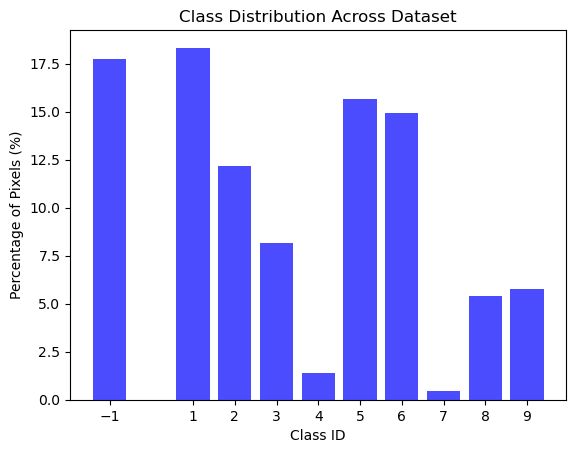

{1: 18.332443340824288,
 2: 12.154766274274932,
 3: 8.181824807072593,
 4: 1.407800309531886,
 5: 15.650532074181648,
 6: 14.925066716311907,
 7: 0.4619624268571913,
 8: 5.392708642511872,
 9: 5.759052085100068,
 -1: 17.733843323333616}

In [181]:
calculate_overall_class_distribution(filtered_labels)


### <a id='toc5_4_3_'></a>[Segregate the labels based on the class](#toc0_)

In [ ]:
def calculate_class_distribution(labels_patch):
    """
    Calculate the class distribution for a single patch.
    
    Parameters:
    - labels_patch: numpy array of shape (64, 64), representing the label for the patch.
    
    Returns:
    - class_percentage: dictionary with the class ID as key and percentage of pixels for that class.
    """
    # Flatten the patch for easy counting
    flattened_patch = labels_patch.flatten()
    
    # Calculate class counts
    class_counts = {i: np.sum(flattened_patch == i) for i in range(1,10)}  # Assuming 10 classes
    
    # Calculate total pixels in the patch
    total_pixels = flattened_patch.size
    
    # Calculate percentage of each class
    class_percentage = {cls: (count / total_pixels) * 100 for cls, count in class_counts.items()}
    
    return class_percentage


In [ ]:
def filter_class_based_data_patches(labels, data, threshold=0.75):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (n, 64, 64)
    - data: numpy array of shape (n, 64, 64, 4)
    - threshold: threshold percentage for class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """

    #Creating a dictionary for classifing the pathes into majority classes deceided by the threshold value
    classified_data = {i:np.array([]) for i in CROP_IDS}
    classified_labels = {i:np.array([]) for i in CROP_IDS}

    #Adding a new patch which has no clear majority
    classified_data[0] = np.array([])
    classified_labels[0] = np.array([])

    for i in range(labels.shape[0]):
        data_patch = data[i,...]
        label_patch = labels[i,...]

        class_distribution = calculate_class_distribution(labels[i,...])
        total_crop_percentage =  sum(class_distribution.values())
        classification_margin = threshold * total_crop_percentage

        #If the patch has a clear majority class, add it to the corresponding list in the dictionary
        if(max(class_distribution.values())>classification_margin):
            major_crop_id = max(class_distribution, key=class_distribution.get)
            #print(major_crop_id, class_distribution)
            classified_data[major_crop_id].append(data_patch)
            classified_labels[major_crop_id].append(label_patch)
        else:
            classified_data[0].append(data_patch)
            classified_labels[0].append(label_patch)
        
    #classified_data[label_patch[0,0]].append(data_patch)
    return classified_data, classified_labels


In [138]:
classified_data, classified_labels = filter_class_based_data_patches(filtered_labels, filtered_data, threshold=0.6)

for i in classified_data.keys():
    print(f"Class: {i}, Count: {len(classified_data[i])}")


Class: -1, Count: 0
Class: 1, Count: 449
Class: 2, Count: 297
Class: 3, Count: 164
Class: 4, Count: 22
Class: 5, Count: 382
Class: 6, Count: 351
Class: 7, Count: 5
Class: 8, Count: 91
Class: 9, Count: 118
Class: 0, Count: 1069


# <a id='toc6_'></a>[Data Augumentation](#toc0_)

In [165]:
def get_augmentations():
    return TA.Compose([
        TA.HorizontalFlip(p=0.75),
        TA.VerticalFlip(p=0.75),
        TA.RandomRotate90(p=0.75),  # Only rotate in 90° steps
        TA.RandomCrop(height=56, width=56, p=0.75),
        TA.Resize(height=64, width=64, p=1.0),
    ], additional_targets={'mask': 'mask'})

def augment_patches(image_patches, label_patches, n_augmentations=5):
    augmented_images = []
    augmented_labels = []
    transform = get_augmentations()

    for img, mask in zip(image_patches, label_patches):
        for _ in range(n_augmentations):
            # Albumentations expects channels-first: HWC, not CHW
            augmented = transform(image=img, mask=mask)
            aug_img = augmented['image']
            aug_mask = augmented['mask']

            augmented_images.append(aug_img)
            augmented_labels.append(aug_mask)

    return np.array(augmented_images), np.array(augmented_labels)


## <a id='toc6_1_'></a>[Visualising sample agugumentation](#toc0_)

In [166]:
sample_augumented_data, sample_agumenmted_labels = augment_patches(filtered_data[:2,...], filtered_labels[:2,...])


In [167]:
sample_augumented_data.shape


(10, 64, 64, 4)

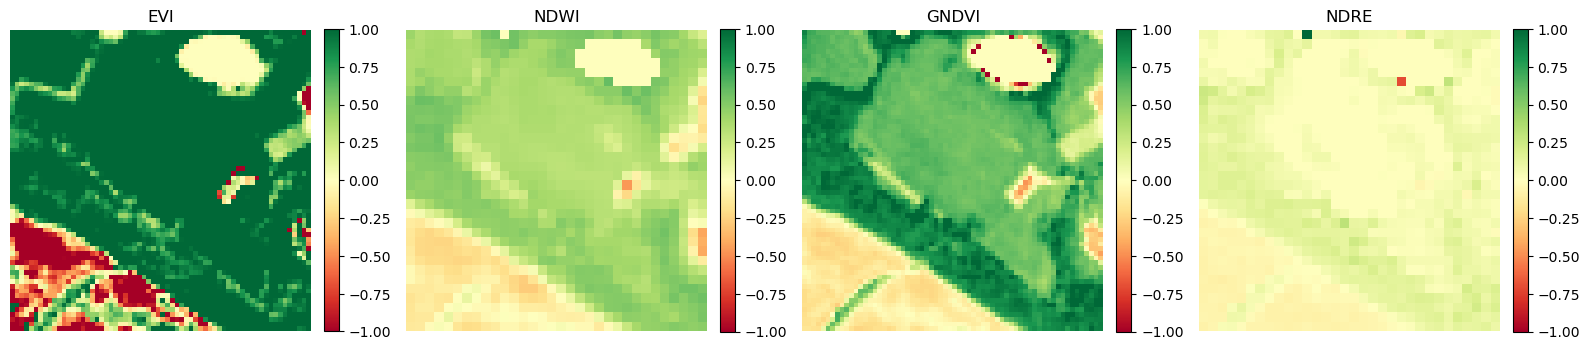

In [121]:
display_images(filtered_data[1:2,...])


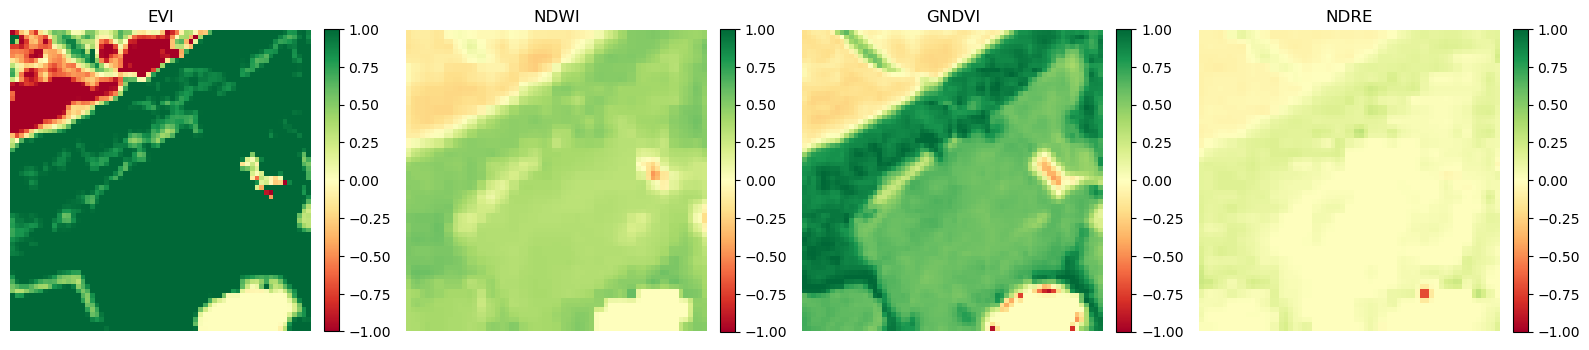

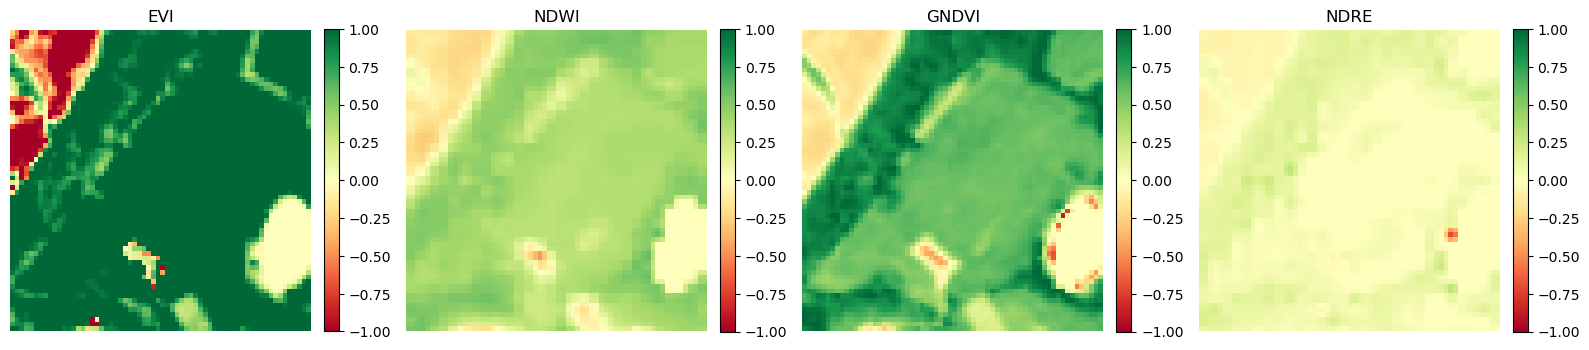

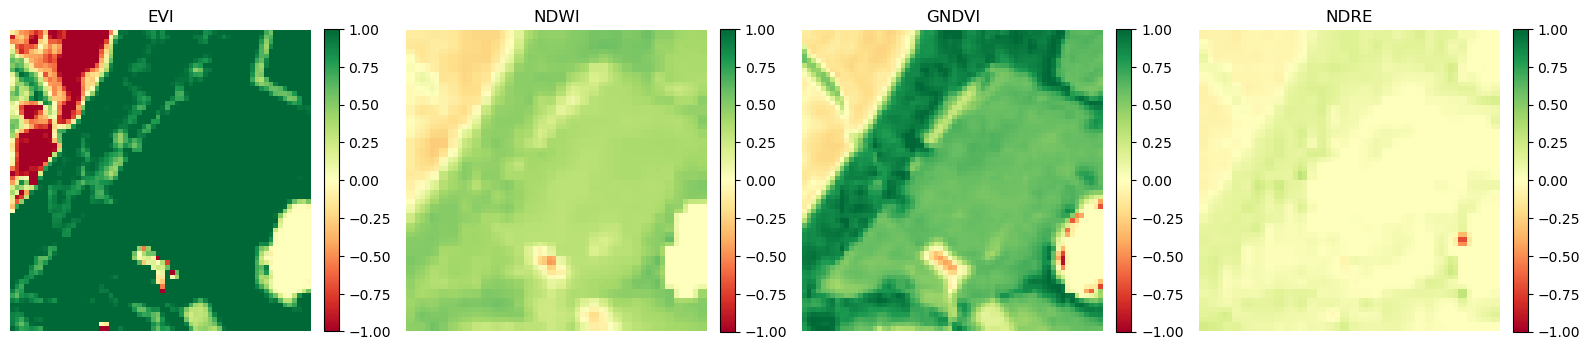

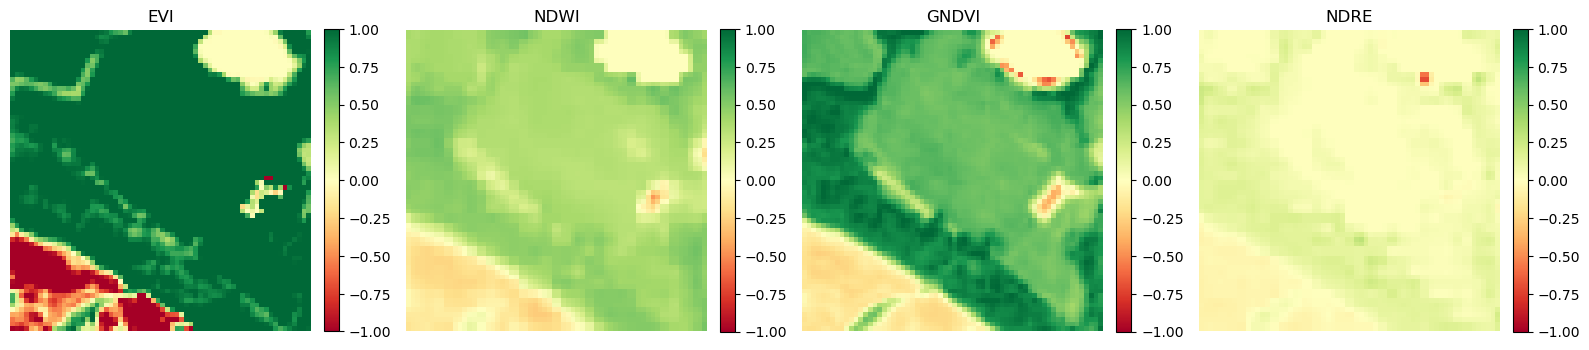

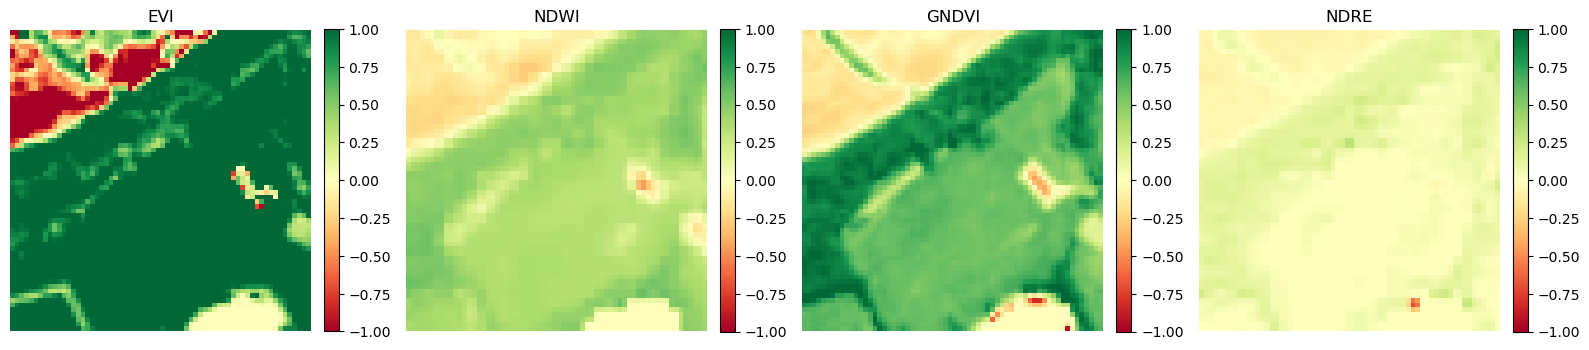

In [122]:
display_images(sample_augumented_data[5:10])


## <a id='toc6_2_'></a>[Augumentation by class](#toc0_)

In [178]:
no_of_total_images = 500

# Initialise empty arrays with desired target shape
agumenmted_labels = np.empty((0, 64, 64))
augumented_data = np.empty((0, 64, 64, 4))

for i in tqdm(classified_data.keys(), total=len(classified_data.keys())):
    if i in range(1,10):
        no_of_original_images = len(classified_data[i])
        required_images = no_of_total_images - no_of_original_images

        if no_of_original_images < no_of_total_images:
            agumentations = int(required_images / no_of_original_images) or 1
            
            if(required_images>no_of_original_images):
                class_augumented_data, class_agumenmted_labels = augment_patches(classified_data[i], classified_labels[i], n_augmentations=agumentations)
            else:
                data = np.array(classified_data[i])[:required_images,...]
                labels = np.array(classified_labels[i])[:required_images,...]
                class_augumented_data, class_agumenmted_labels = augment_patches(data, labels, 1)

            print(f"Class {i} | No of agumented images: {class_augumented_data.shape[0]} | No of total imgaes: {(class_augumented_data.shape[0]+no_of_original_images)}")
            augumented_data = np.concatenate((augumented_data, class_augumented_data), axis=0)
            agumenmted_labels = np.concatenate((agumenmted_labels, class_agumenmted_labels), axis=0)
        else:
            print(f"Class {i} | No of agumented images: 0 | No of total imgaes: {no_of_original_images}")
        
print(f"Total no of agumented images: {augumented_data.shape[0]}")



final_gan_data = np.empty((0, 64, 64, 4))
final_gan_labels = np.empty((0, 64, 64))

for i in classified_data.keys():
    if len(classified_data[i])>0:
        data = np.array(classified_data[i])
        labels = np.array(classified_labels[i])

        final_gan_data = np.concatenate((final_gan_data, data), axis=0)
        final_gan_labels = np.concatenate((final_gan_labels, labels), axis=0)

final_gan_data = np.concatenate((final_gan_data, augumented_data), axis=0)
final_gan_labels = np.concatenate((labels, agumenmted_labels), axis=0)

print(f"Total no of original images: {filtered_data.shape[0]}")
print(f"Total no of images: {final_gan_data.shape[0]}")
    


 36%|███▋      | 4/11 [00:00<00:00, 24.21it/s]

Class 1 | No of agumented images: 51 | No of total imgaes: 500
Class 2 | No of agumented images: 203 | No of total imgaes: 500
Class 3 | No of agumented images: 328 | No of total imgaes: 492
Class 4 | No of agumented images: 462 | No of total imgaes: 484
Class 5 | No of agumented images: 118 | No of total imgaes: 500
Class 6 | No of agumented images: 149 | No of total imgaes: 500


 64%|██████▎   | 7/11 [00:00<00:00, 14.50it/s]

Class 7 | No of agumented images: 495 | No of total imgaes: 500
Class 8 | No of agumented images: 364 | No of total imgaes: 455


100%|██████████| 11/11 [00:00<00:00, 11.80it/s]


Class 9 | No of agumented images: 354 | No of total imgaes: 472
Total no of agumented images: 2524
Total no of original images: 2948
Total no of images: 5472


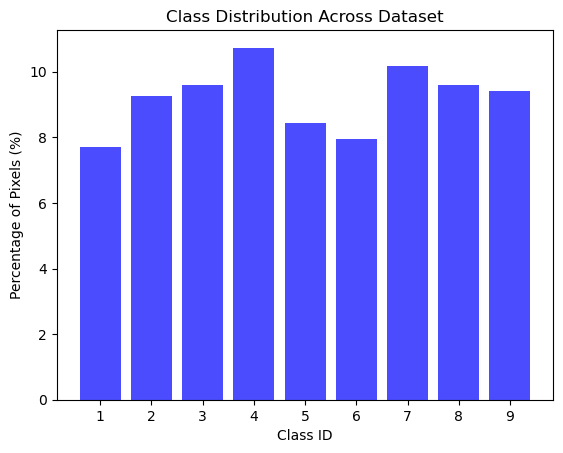

{1: 7.7059356409163655,
 2: 9.266913584139298,
 3: 9.605224677323964,
 4: 10.732776568588227,
 5: 8.429551330277624,
 6: 7.96021425123504,
 7: 10.179692392325355,
 8: 9.601351586418035,
 9: 9.401194325337462}

In [ ]:
calculate_overall_class_distribution(final_gan_labels, False)


### <a id='toc6_2_1_'></a>[Save augmented and original(filtered) data](#toc0_)

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/7_augumented_data_64X64_majority60.npy', augumented_data) 
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/8_augumented_labels_64X64_majority60.npy', agumenmted_labels) 


In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/9_augumented_data_64X64.npy', filtered_data) 
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/10_augumented_labels_64X64.npy', filtered_labels) 
